# Tutorial 1 — optimizing an ADI reduction of β Pictoris (VLT/NACO L′)

**klip-tpe** searches the parameter space of a KLIP/ADI reduction (KL modes, temporal
binning, high-pass filter, azimuthal zones, reference exclusion angles, frame selection,
which nights/groups to combine) with a Tree-structured Parzen Estimator, scoring every
trial by the S/N of fake companions injected at fresh random positions, then
*validates* the best candidates on independent injections so the winner is not a lucky
draw.  It is the Python port of the optimizer used for the NEAR/VISIR and LBTI/NOMIC
mid-infrared campaigns, with the same live display and product set.

This notebook runs the whole pipeline on a small public data set — the VIP tutorial
sequence of β Pictoris (NACO L′, 61 frames, 101×101 px, Absil et al. 2013), which contains
the planet β Pic b at ~0.45″.  It takes a few minutes on a laptop.

```
pip install "klip-tpe[plots]"          # or: pip install -e ".[plots]" from a clone
```
Everything below also works from a terminal (`klip-tpe generic ...`) — see the last section.

In [1]:
import os, json, time
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

from klip_tpe import Runner, RunConfig, ValidationConfig, CalibrationConfig
from klip_tpe import datasets
from klip_tpe.instruments import generic
from klip_tpe.display import LiveDisplay

RUN_DIR = os.path.abspath("runs/betapic_naco")      # everything the run produces goes here
# Re-running this notebook RESUMES that directory: a finished annulus is reported complete
# in 0.0 min and no new panels are drawn.  Delete runs/betapic_naco to search again.

## 1. The data

`klip_tpe.datasets.fetch` downloads (once, into `~/.klip_tpe/data`) the three files of
the VIP data set: the registered cube, the derotation angles and an unsaturated PSF.

In [2]:
files = datasets.fetch("naco_betapic")
files

{'cube': '/root/.klip_tpe/data/naco_betapic_cube_cen.fits',
 'angles': '/root/.klip_tpe/data/naco_betapic_derot_angles.fits',
 'psf': '/root/.klip_tpe/data/naco_betapic_psf.fits'}

(61, 101, 101) (61,) (39, 39) field rotation 81.4 deg


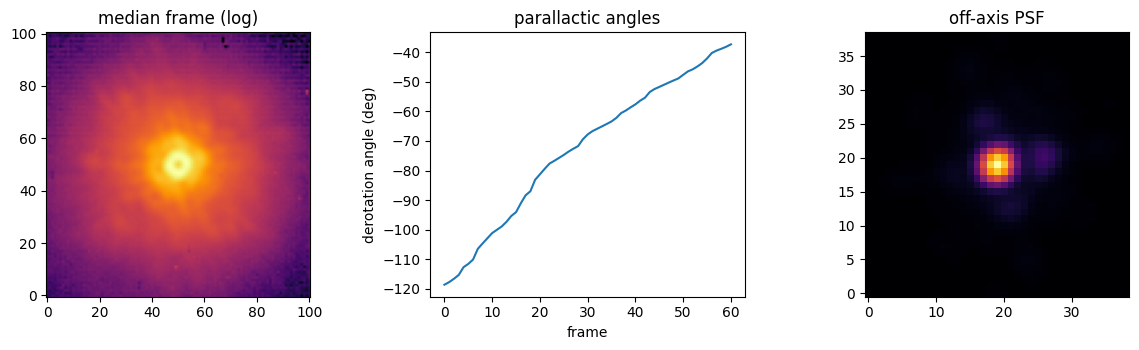

In [3]:
cube = fits.getdata(files["cube"]); angles = fits.getdata(files["angles"]); psf = fits.getdata(files["psf"])
print(cube.shape, angles.shape, psf.shape, f"field rotation {np.ptp(angles):.1f} deg")
fig, ax = plt.subplots(1, 3, figsize=(12, 3.6))
ax[0].imshow(np.log10(np.clip(np.nanmedian(cube, 0), 1, None)), origin="lower", cmap="inferno"); ax[0].set_title("median frame (log)")
ax[1].plot(angles); ax[1].set_xlabel("frame"); ax[1].set_ylabel("derotation angle (deg)"); ax[1].set_title("parallactic angles")
ax[2].imshow(psf, origin="lower", cmap="inferno"); ax[2].set_title("off-axis PSF")
plt.tight_layout()

## 2. Dataset → reducer → search space

The *generic* adapter takes any registered cube.  Three conventions matter:

* **angles** – klip-tpe derotates each frame counter-clockwise by `angle` (same sign as
  VIP's `angle_list` / pyKLIP's `PAs`); use `angle_sign=-1` for the opposite convention.
* **star flux** – injected companions are expressed as a *contrast*, so an absolute
  contrast axis needs the star's flux **in the science frames' own units and in the
  template's normalisation aperture**.  Neither of these two files carries it.  The science
  frames are AGPM coronagraphic (the radial profile is suppressed inside ~3 px — the star
  is occulted, not saturated), so you cannot read the star off them; and the distributed
  `naco_betapic_psf.fits` is a *normalised* template — its flux inside r = 2.000 px is
  1.000000000 — so its counts are not β Pictoris either.  Leave `star_flux` unset and
  `TemplatePSF` falls back to the stamp's own sum, 4.349, which puts the "contrast" axis a
  factor of 9.4 × 10⁵ away from a contrast.  A normalised template is the easiest way to
  get a plausible-looking axis that means nothing.

  What is needed is photometry the *observer* made.  `datasets.PHOTOMETRY` carries VIP's
  published `starphot = 764939.6` for this very cube — measured on the non-coronagraphic
  PSF and rescaled to the coronagraphic integration time, in the same 2 px aperture the
  template is normalised in — and `star_flux_from_aperture_photometry` converts it into the
  normalisation `TemplatePSF` uses.  **And then it gets checked**: with that star flux,
  β Pic b measures ΔL′ = 7.81 ± 0.08 against the 8.01 ± 0.16 that Absil et al. (2013)
  published from these same data — 1.1 σ.  `scripts/check_betapic_contrast.py` is that
  measurement; run it if you change anything upstream of the axis.

  A `star_flux_from_halo` helper used to stand here instead, scaling the template to the
  science halo at 6–14 px.  It has been removed: fitting an off-axis template to a
  *coronagraphic* halo compares two different functions, and it showed — the same method on
  the same data returned fluxes 5.28× and 8.04× apart on paper runs A2 and B2, and both were
  wrong.  Use photometry, or say "template units" and mean it.
* **frame-quality tags** – the searched frame-selection thresholds (`corr_thresh`,
  `noise_max`, `coronoise_max`) act on per-frame tags.  When the data bring none, the
  adapter derives them from the cube itself (`quality_tags`).

`INSTRUMENT` holds the plate scale, wavelength and aperture (λ/D = 3.5 px here).

`make_space` scales the parameter ranges to *these* data: KL modes up to `nframes/5`,
and temporal binning up to `nframes/8` frames per bin so that at least eight bins — and
therefore enough KLIP references — always survive.  (The NEAR production range is 5–30
frames per bin; on a 61-frame cube that would leave two bins and no real subtraction.
`bin_range=(lo, hi)` sets it by hand.)

In [4]:
inst = datasets.INSTRUMENT["naco_betapic"]
ds = generic.load_cube(files["cube"], files["angles"], psf=files["psf"], name="betapic")
print(f"tags: {list(ds.tags)}")

phot = datasets.PHOTOMETRY["naco_betapic"]
star_flux = generic.star_flux_from_aperture_photometry(psf, phot["starphot"], phot["aperture_px"])
print(f"template sum {psf.sum():.4f}, flux in r={phot['aperture_px']} px "
      f"{generic.aperture_sum(psf, 19, 19, phot['aperture_px']):.9f} -> star_flux {star_flux:.4g}")

red = generic.make_reducer({"betapic": ds}, star_flux=star_flux, max_workers="auto", **inst)
space = generic.make_space(red, k_klip_max=30)      # 61 frames -> <=30 KL modes, <=7 frames per temporal bin
space.project = generic.make_guard(red, k_max=30)   # feasibility: enough references per frame etc.
objective, sampler = generic.default_config(red, known=[(0.452, 211.9)])   # keep injections away from beta Pic b
print(space.names)

tags: ['corrs', 'noises', 'coronoise']
template sum 4.3491, flux in r=2.0 px 0.999999998 -> star_flux 3.327e+06
  betapic: 61 frames 101x101 px, PA span 81.4 deg, injection template (flux unit 3.33e+06), fwhm 3.61 px, lambda/D 3.52 px
['bin', 'n_ang', 'filter', 'angsep', 'anglemax', 'corr_thresh', 'noise_max', 'coronoise_max', 'k_klip']


A single reduction with the default parameters (0.3 s) already shows β Pic b at the
expected place (0.452″, PA 211.9°):

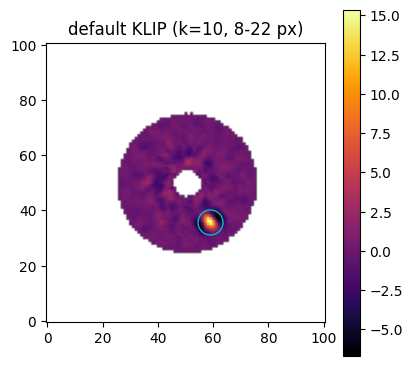

In [5]:
from klip_tpe.reducer import ReductionRequest
cfg0 = space.decode(space.default_vector())
res = red.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=22, k_klip=10)))
rho_px = 0.452 / inst["pxscale"]; pa = np.deg2rad(211.9)
xb, yb = 50 - rho_px * np.sin(pa), 50 + rho_px * np.cos(pa)
plt.figure(figsize=(4.5, 4.5)); plt.imshow(res.image, origin="lower", cmap="inferno"); plt.plot(xb, yb, "o", mfc="none", mec="c", ms=18)
plt.title("default KLIP (k=10, 8-22 px)"); plt.colorbar();

## 3. Configure the optimization

One annulus, 8–22 px, 60 evaluations of which 15 random warm-up; the two best candidates
are validated on 3 fresh injection sets each.  The injection contrast is *calibrated*
automatically so that the default configuration detects the fakes at S/N ≈ 5 (parameters
matter most where the companion is marginal); `CalibrationConfig(forced=[c])` fixes it.

**The annulus is where the optimization happens.**  Companions are injected at the
area-weighted mid radius of the annulus — √((8² + 22²)/2) = 16.6 px = 0.45″ here, i.e. at
β Pic b's separation, so the parameters are tuned for the region we care about.  A wider
annulus tunes for its own mid radius, which may be nowhere near your target.

Production runs use thousands of evaluations; the protocol is the same.

In [6]:
cfg = RunConfig(ann_edges=[8, 22], n_iter=60, n_init=15, seed=1,
                validation=ValidationConfig(n_top=2, n_valid=3),
                calibration=CalibrationConfig(target=(4.0, 6.0), aim=5.0, n_remeasure=2),
                defaults={"k_klip": 10}, fm_curve=True)

## 4. Run with the live display

`LiveDisplay(show="inline")` updates the panel in this output cell after every
evaluation (`show=True` opens it in a matplotlib window instead; `show="auto"` picks).
The same PNGs are written to `steps/`, a progress movie is rebuilt every 10 evaluations
(`annulus01/progress.gif`), and the books (corner, importance, landscapes, products,
verification) are written at the end of the annulus.

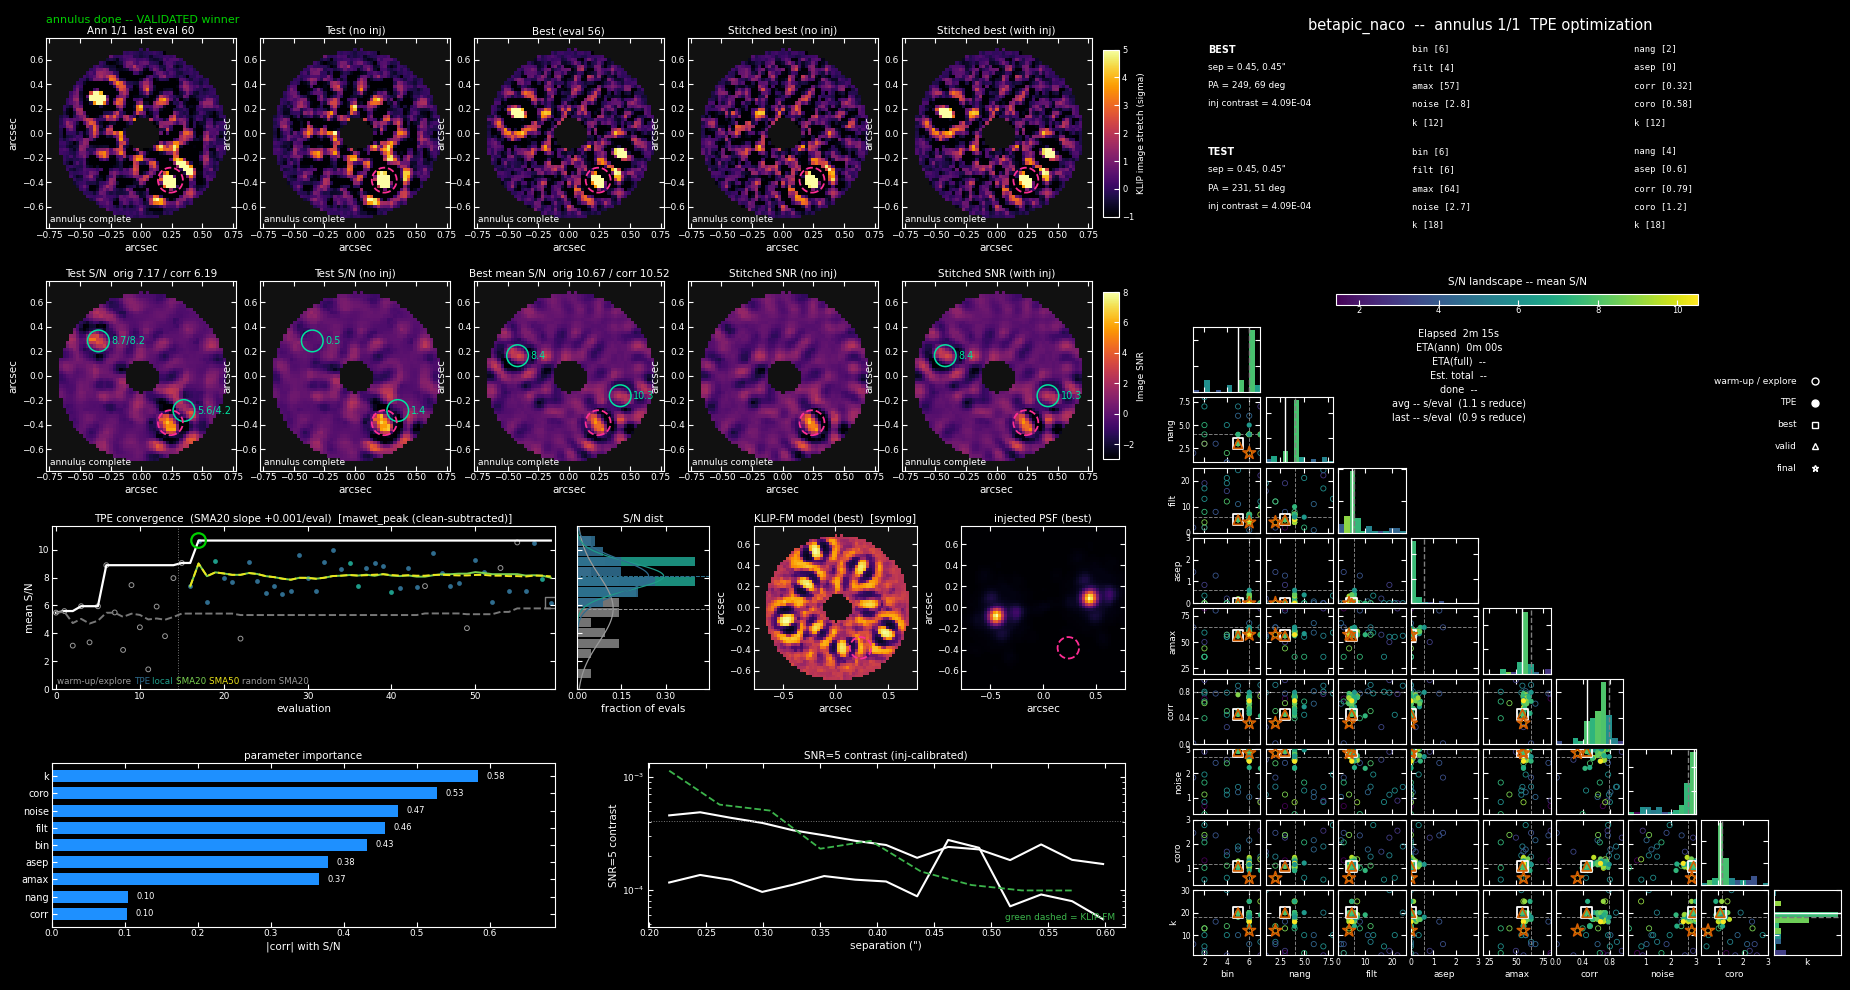

=== annulus 1/1: [8.0, 22.0] px, 2 sources, band 0.450-0.450"


  calibration k-scan: k_default = 7


  calibration trial 1: contrast=3.000e-05  median S/N=-0.08


  calibration trial 2: contrast=3.000e-04  median S/N=3.67


  calibration trial 3: contrast=4.090e-04  median S/N=5.02


...

param_verify config 13/14 (eval 50, score 4.37)


param_verify config 14/14 (eval 23, score 3.62)


param_verify annulus 01: 14 configs; combine K~7.866E+03


run complete: 1 annuli, 60 evaluations


  [display] movie: ['/home/claude/klip-tpe-py/tutorials/runs/betapic_naco/opt_steps.gif', '/home/claude/klip-tpe-py/tutorials/runs/betapic_naco/opt_steps.mp4']
done in 2.5 min


In [7]:
display = LiveDisplay(RUN_DIR, show="inline", window_scale=0.55, movie_every=10)
runner = Runner(red, space, objective, sampler, cfg, RUN_DIR, callbacks=[display])
t0 = time.time()
results = runner.run()
print(f"done in {(time.time() - t0) / 60:.1f} min")

## 5. Results

`results` holds one `AnnulusResult` per annulus; the same numbers are in
`final_results.json`, `annulus01/winner.json` and the human-readable `results.txt`.

In [8]:
r = results[0]
print(f"search best: eval {r.search_best_index + 1}, S/N {r.search_best_score:.2f}")
print(f"winner:      eval {r.winner_index + 1}, validated {r.validated}, validation median S/N {r.winner_score:.2f}")
print("winner parameters:", {k: v for k, v in r.winner_config['params'].items() if k in space.names})
print("validation table (candidate, trials):")
for row in r.validation_table:
    print(f"   eval {row['eval_index'] + 1}: search S/N {row['search_score']:.2f} -> validation trials "
          f"{np.round(row['trials'], 2)} (median {row['validated_score']:.2f})")

search best: eval 18, S/N 10.66
winner:      eval 56, validated True, validation median S/N 9.36
winner parameters: {'bin': 6, 'n_ang': 2, 'filter': 4, 'angsep': 0.0, 'anglemax': 57, 'corr_thresh': 0.3199538361749259, 'noise_max': 2.8435084920578735, 'coronoise_max': 0.5827641282347515, 'k_klip': 12}
validation table (candidate, trials):
   eval 18: search S/N 10.66 -> validation trials [8.58 9.17 6.71] (median 8.58)
   eval 56: search S/N 10.52 -> validation trials [ 9.36 10.07  8.99] (median 9.36)


The winner's reduction with and without the injected companions, and the final clean
image (β Pic b, no injections).  The real planet is an independent check: it was never
injected, and its S/N is measured with the same matched-filter statistic:

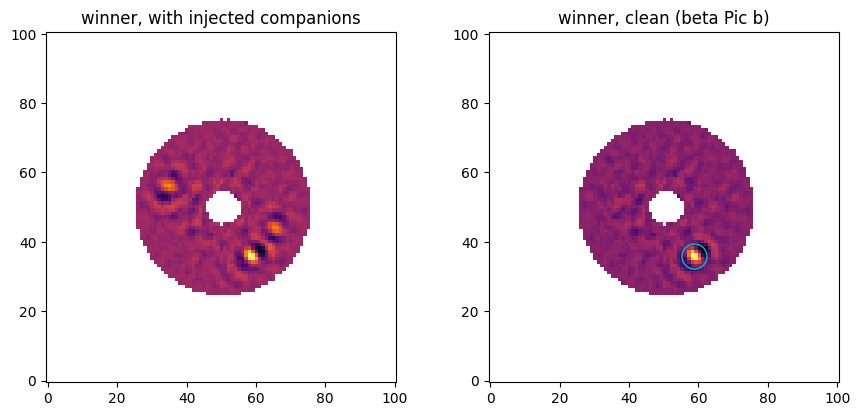

In [9]:
best_inj = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_inj.fits"))
best_clean = fits.getdata(os.path.join(RUN_DIR, "annulus01", "best_clean.fits"))
fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
for a, im, t in zip(ax, (best_inj, best_clean), ("winner, with injected companions", "winner, clean (beta Pic b)")):
    a.imshow(im, origin="lower", cmap="inferno"); a.set_title(t)
ax[1].plot(xb, yb, "o", mfc="none", mec="c", ms=18); plt.tight_layout()

In [10]:
from klip_tpe.metrics import MawetPeakSNR
metric = MawetPeakSNR(pxscale=red.pxscale, fwhm=red.fwhm, kernel_fn=red.matched_filter_kernel)
snr_default = metric.per_source(res.image, None, [0.452], [211.9])[0]
snr_winner = metric.per_source(best_clean, None, [0.452], [211.9])[0]
print(f"beta Pic b: S/N {snr_default:.1f} (default)  ->  {snr_winner:.1f} (validated winner)")
print(f"injected companions: S/N ~5 (calibrated default)  ->  {r.winner_score:.1f} (validated winner)")

beta Pic b: S/N 16.1 (default)  ->  18.6 (validated winner)
injected companions: S/N ~5 (calibrated default)  ->  9.4 (validated winner)


The gain on the *injections* (≈5 → 9) is larger than on the planet (16 → 19): the
injections sit near the detection limit, where the parameters matter most, while β Pic b
is far above it.  To tune for a bright known companion, force the injection contrast to
its own with `CalibrationConfig(forced=[c])`.

Contrast curve (5σ, injection-calibrated throughput) of the validated winner, plus the
KLIP forward-model cross-check.  Known companions passed as `known=` are excluded from
the noise rings, so β Pic b does not inflate its own detection limit:

Text(0.5, 1.0, "beta Pic, NACO L'")

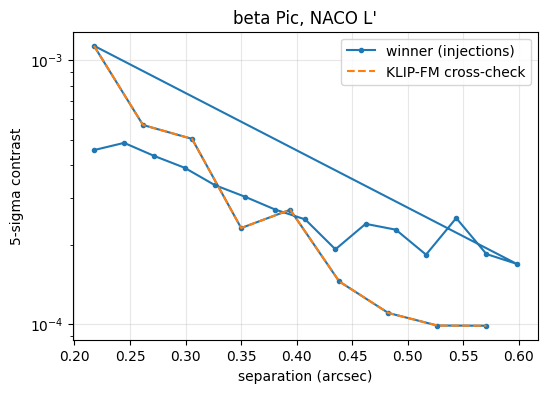

In [11]:
cc = np.loadtxt(os.path.join(RUN_DIR, "annulus01", "contrast_curve.txt"))
plt.figure(figsize=(6, 4)); plt.semilogy(cc[:, 0], cc[:, 1], "-o", ms=3, label="winner (injections)")
if r.fm_curve:
    plt.semilogy(r.fm_curve["r_as"], r.fm_curve["curve"], "--", label="KLIP-FM cross-check")
plt.xlabel("separation (arcsec)"); plt.ylabel("5-sigma contrast"); plt.legend(); plt.grid(alpha=.3); plt.title("beta Pic, NACO L'")

Everything else lives in the run directory — the step frames and movie, and the books:

| file | content |
|---|---|
| `steps/stepNNNN.png`, `annulus01/progress.gif`, `opt_steps.gif` | the live panel per evaluation and the movie |
| `annulus01/corner.pdf`, `landscapes.pdf` | the sampled parameter space, coloured by S/N |
| `annulus01/importance.pdf`, `paracoord.pdf`, `rank.pdf`, `slice.pdf` | which parameters matter |
| `annulus01/products.pdf`, `verify_limits.pdf`, `verify_subsets_inj.pdf` | winner images, S/N maps, detection limits |
| `annulus01/validation_panel.png`, `calibration_panel.png` | the validation and calibration stages |
| `klip_stitched*.fits`, `contrast_curve.txt`, `results.txt` | final images and tables |

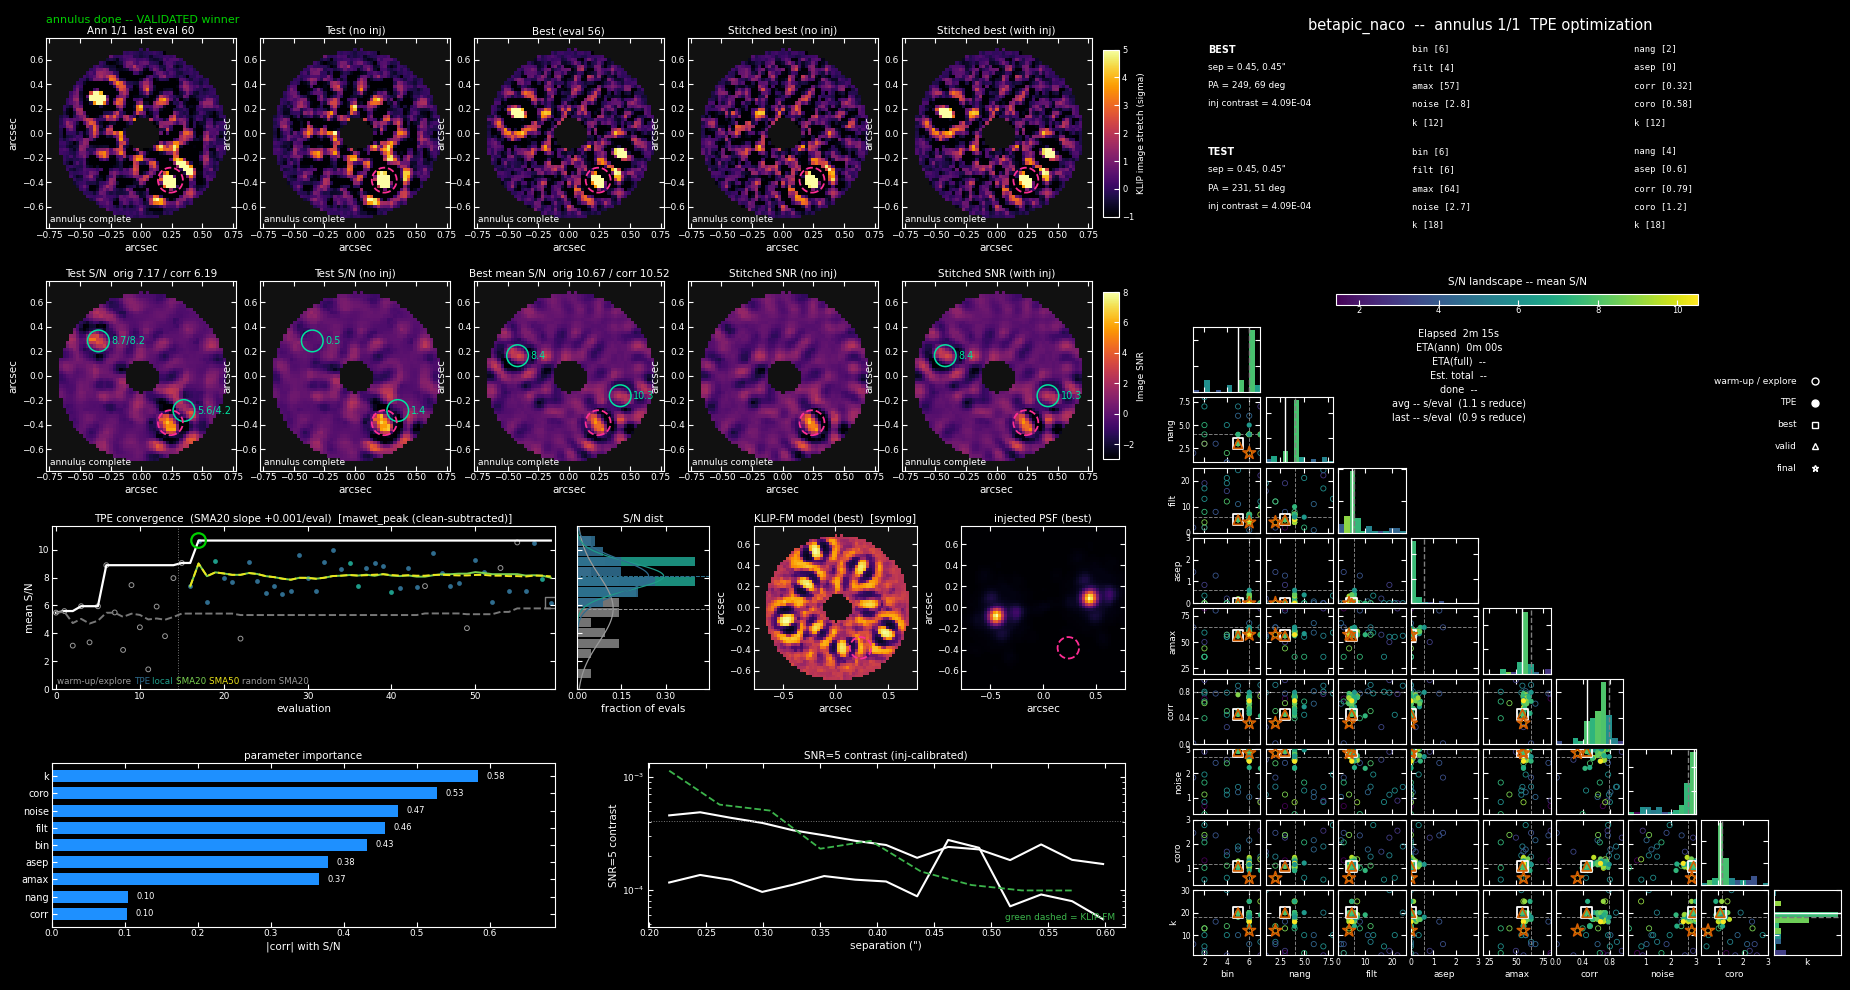

In [12]:
from IPython.display import Image
last_frame = sorted(f for f in os.listdir(os.path.join(RUN_DIR, "steps")) if f.startswith("step"))[-1]
Image(filename=os.path.join(RUN_DIR, "steps", last_frame), width=1000)     # the annulus-end frame

In [13]:
sorted(os.listdir(os.path.join(RUN_DIR, "annulus01")))[:40]

['best_clean.fits',
 'best_clean_partitions.fits',
 'best_fm.fits',
 'best_inj.fits',
 'best_inj_partitions.fits',
 'calib0001_setup.txt',
 'calib0002_setup.txt',
 'calib0003_setup.txt',
 'calibration.json',
 'calibration_panel.png',
 'contrast_curve.txt',
 'corner.pdf',
 'edf.png',
 'eval0001_setup.txt',
 'eval0002_setup.txt',
 'eval0003_setup.txt',
 'eval0004_setup.txt',
 'eval0005_setup.txt',
 'eval0006_setup.txt',
 'eval0007_setup.txt',
 'eval0008_setup.txt',
 'eval0009_setup.txt',
 'eval0010_setup.txt',
 'eval0011_setup.txt',
 'eval0012_setup.txt',
 'eval0013_setup.txt',
 'eval0014_setup.txt',
 'eval0015_setup.txt',
 'eval0016_setup.txt',
 'eval0017_setup.txt',
 'eval0018_setup.txt',
 'eval0019_setup.txt',
 'eval0020_setup.txt',
 'eval0021_setup.txt',
 'eval0022_setup.txt',
 'eval0023_setup.txt',
 'eval0024_setup.txt',
 'eval0025_setup.txt',
 'eval0026_setup.txt',
 'eval0027_setup.txt']

## 6. Other PSF-subtraction engines: VIP and pyKLIP

The optimizer does not care who subtracts the PSF.  `backend="vip"` (VIP's
`pca_annular`) or `backend="pyklip"` (`klip_parallelized`) replace the KLIP core and keep
the injection, frame selection, filtering, binning and scoring — so the same search space
can be compared across engines on the same data.  A single reduction each:

In [14]:
for backend in ("klip", "vip", "pyklip"):
    try:
        red_b = generic.make_reducer({"betapic": ds}, star_flux=star_flux, backend=backend, log=lambda s: None, **inst)
    except Exception as exc:                      # engine not installed
        print(f"{backend}: {exc}"); continue
    t = time.time()
    img = red_b.reduce(ReductionRequest(params=dict(cfg0.params, inrad=8, outrad=30, k_klip=10))).image
    print(f"{backend:7s} {time.time() - t:5.1f} s   peak {np.nanmax(img):.1f} at {np.unravel_index(np.nanargmax(np.nan_to_num(img, nan=-1e9)), img.shape)[::-1]}")

klip      0.1 s   peak 14.5 at (np.int64(58), np.int64(36))


vip       1.3 s   peak 42.3 at (np.int64(59), np.int64(36))


pyklip    0.1 s   peak 38.4 at (np.int64(58), np.int64(36))


To optimize with another engine, build the reducer with `backend=` and run exactly the
same cells (`Runner(...)`), e.g. `RUN_DIR + "_vip"`.  Note that KLIP-FM (the forward-model
cross-check curve) exists only for the built-in engine.

## 7. The same from a terminal

```
klip-tpe generic --cube naco_betapic_cube_cen.fits --angles naco_betapic_derot_angles.fits \
    --psf naco_betapic_psf.fits --star-flux 3.3268e6 --pxscale 0.02719 --lam 3.8e-6 --diam 8.2 \
    --known 0.452 211.9 --ann-edges 8 30 --n-iter 60 --n-init 15 --n-top 2 --n-valid 3 \
    --run-dir runs/betapic_cli --show           # --show inline inside Jupyter, --backend vip|pyklip
klip-tpe resume --run-dir runs/betapic_cli      # after an interruption
klip-tpe plots  --run-dir runs/betapic_cli      # regenerate the figures
```

## 8. Your own data

Anything registered on the star works: `generic.load_cube(cube, angles, psf=...,
ref_cube=...)` accepts arrays or FITS paths (a 4-d IFS cube with `wv_index=`), several
`Dataset`s (nights, epochs, IRDIS channels, pyNOMIC image groups …) become *partitions*
that the optimizer tunes and selects individually, and `ref_cube` switches on RDI/ARDI.
For pyNOMIC reductions use the dedicated adapter (`klip-tpe near --instrument nomic`);
for JWST see tutorial 3.